In [ ]:
# https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [97]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [98]:
df = pd.read_csv("creditcard.csv")[:80000]

In [99]:
df.shape

(80000, 31)

In [100]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [101]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [102]:
(df.Class==0).sum()

np.int64(79804)

In [103]:
(df.Class==1).sum()

np.int64(196)

In [104]:
X = df.drop(columns=['Time','Amount','Class']).values
y = df['Class'].values

In [105]:
f"Shape of X={X.shape}, #Fraud Cases={y.sum()}"

'Shape of X=(80000, 28), #Fraud Cases=196'

## Logestic regression

The class_weight parameter handles imbalanced data by telling the model to pay more attention to underrepresented or highly important classes.

In your specific configuration {0:1, 1:2}, the model places twice as much penalty on mistakes made on class 1 compared to class 0.



Imbalanced Datasets: Used when you have twice as many instances of class 0 as class 1.

In [42]:
from sklearn.linear_model import LogisticRegression
# use class to balance 
model = LogisticRegression(class_weight={0:1,1:2},max_iter=1000)
# class 0 "none froud"
model.fit(X,y)
pred = model.predict(X)
pred.sum()

np.int64(172)

## using gridsearch cv to find the best weight

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV


grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid = {'class_weight':[{0:1,1:v} for v in range(1,4)]},
    cv = 4,
    n_jobs=-1 # use 100% available cpu
)

grid.fit(X,y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 2}, ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed d

In [47]:
pd.DataFrame(grid.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_class_weight,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
0,0.395957,0.093625,0.005274,0.001257,"{0: 1, 1: 1}","{'class_weight': {0: 1, 1: 1}}",0.8431,0.99835,0.99950,0.99785,0.959700,0.067322,1
1,0.382850,0.068515,0.005798,0.000815,"{0: 1, 1: 2}","{'class_weight': {0: 1, 1: 2}}",0.8190,0.99840,0.99965,0.99805,0.953775,0.077815,2
2,0.406370,0.089300,0.003632,0.000414,"{0: 1, 1: 3}","{'class_weight': {0: 1, 1: 3}}",0.7089,0.99845,0.99960,0.99815,0.926275,0.125503,3


> to see the current score metrics use this

In [53]:
lr = LogisticRegression()
??lr.score

Signature: lr.score(X, y, sample_weight=None)
Source:   
    def score(self, X, y, sample_weight=None):
        """
        Return :ref:`accuracy <accuracy_score>` on provided data and labels.

        In multi-label classification, this is the subset accuracy
        which is a harsh metric since you require for each sample that
        each label set be correctly predicted.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            Test samples.

        y : array-like of shape (n_samples,) or (n_samples, n_outputs)
            True labels for `X`.

        sample_weight : array-like of shape (n_samples,), default=None
            Sample weights.

        Returns
        -------
        score : float
            Mean accuracy of ``self.predict(X)`` w.r.t. `y`.
        """
        from sklearn.metrics import accuracy_score

        return accuracy_score(y, self.predict(X), sample_weight=sample_weight)
File:      c:\users\pkmpp\documents\

## using different metrics

In [57]:
from sklearn.metrics import precision_score, recall_score

# given that i predicted froud how acurate am i
print(precision_score(y,grid.predict(X)))
# did i get all the froud cases
print(recall_score(y,grid.predict(X)))

0.7814569536423841
0.6020408163265306


### adding precision and recall to the grid search

In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, make_scorer


grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid = {'class_weight':[{0:1,1:v} for v in range(1,4)]},
    cv = 4,
    scoring={'precision': make_scorer(precision_score),'recall_score': make_scorer(recall_score)},
    refit='precision', # to tell the gridsearch to chose precision to find the best model
    return_train_score=True,
    n_jobs=-1 # use 100% available cpu
)

grid.fit(X,y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 2}, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'precision': make_scorer(p...hod='predict'), 'recall_score': make_scorer(r...hod='predict')}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'precision'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-f

In [68]:
pd.set_option('display.max_columns', None)
pd.DataFrame(grid.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_class_weight,params,split0_test_precision,split1_test_precision,split2_test_precision,split3_test_precision,mean_test_precision,std_test_precision,rank_test_precision,split0_train_precision,split1_train_precision,split2_train_precision,split3_train_precision,mean_train_precision,std_train_precision,split0_test_recall_score,split1_test_recall_score,split2_test_recall_score,split3_test_recall_score,mean_test_recall_score,std_test_recall_score,rank_test_recall_score,split0_train_recall_score,split1_train_recall_score,split2_train_recall_score,split3_train_recall_score,mean_train_recall_score,std_train_recall_score
0,0.389500,0.062629,0.013066,0.001648,"{0: 1, 1: 1}","{'class_weight': {0: 1, 1: 1}}",0.015071,1.0,0.975610,0.875000,0.716420,0.407626,1,0.976923,0.826923,0.694444,0.765152,0.815861,0.104135,0.979592,0.326531,0.816327,0.142857,0.566327,0.342825,3,0.863946,0.585034,0.510204,0.687075,0.661565,0.132642
1,0.366959,0.047129,0.012558,0.001792,"{0: 1, 1: 2}","{'class_weight': {0: 1, 1: 2}}",0.013090,1.0,0.977273,0.857143,0.711876,0.407080,2,0.977099,0.790323,0.736000,0.771812,0.818808,0.093452,0.979592,0.346939,0.877551,0.244898,0.612245,0.320415,2,0.870748,0.666667,0.625850,0.782313,0.736395,0.096490
2,0.401558,0.071089,0.008808,0.003558,"{0: 1, 1: 3}","{'class_weight': {0: 1, 1: 3}}",0.008179,1.0,0.955556,0.800000,0.690934,0.401122,3,0.969697,0.776119,0.751880,0.779221,0.819229,0.087515,0.979592,0.367347,0.877551,0.326531,0.637755,0.293401,1,0.870748,0.707483,0.680272,0.816327,0.768707,0.077861


## run again with a proper run

In [71]:
for i in np.linspace(1,20,30):
    print(i)

1.0
1.6551724137931034
2.310344827586207
2.9655172413793105
3.6206896551724137
4.275862068965517
4.931034482758621
5.586206896551724
6.241379310344827
6.896551724137931
7.551724137931034
8.206896551724139
8.862068965517242
9.517241379310345
10.172413793103448
10.827586206896552
11.482758620689655
12.137931034482758
12.793103448275861
13.448275862068964
14.103448275862068
14.758620689655173
15.413793103448276
16.06896551724138
16.724137931034484
17.379310344827587
18.03448275862069
18.689655172413794
19.344827586206897
20.0


In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, make_scorer
import numpy as np
import pandas as pd


grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid = {'class_weight':[{0:1,1:v} for v in np.linspace(1,20,30)]},
    cv = 10,
    scoring={'precision': make_scorer(precision_score),'recall': make_scorer(recall_score)},
    refit='precision', # to tell the gridsearch to chose precision to find the best model
    return_train_score=True,
    n_jobs=-1 # use 100% available cpu
)

grid.fit(X,y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [{0: 1, 1: np.float64(1.0)}, {0: 1, 1: np.float64(1.6551724137931034)}, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'precision': make_scorer(p...hod='predict'), 'recall': make_scorer(r...hod='predict')}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'precision'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` d

In [85]:
pd.set_option('display.max_columns',None)
pd.DataFrame(grid.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_class_weight,params,split0_test_precision,split1_test_precision,split2_test_precision,split3_test_precision,split4_test_precision,split5_test_precision,split6_test_precision,split7_test_precision,split8_test_precision,split9_test_precision,mean_test_precision,std_test_precision,rank_test_precision,split0_train_precision,split1_train_precision,split2_train_precision,split3_train_precision,split4_train_precision,split5_train_precision,split6_train_precision,split7_train_precision,split8_train_precision,split9_train_precision,mean_train_precision,std_train_precision,split0_test_recall,split1_test_recall,split2_test_recall,split3_test_recall,split4_test_recall,split5_test_recall,split6_test_recall,split7_test_recall,split8_test_recall,split9_test_recall,mean_test_recall,std_test_recall,rank_test_recall,split0_train_recall,split1_train_recall,split2_train_recall,split3_train_recall,split4_train_recall,split5_train_recall,split6_train_recall,split7_train_recall,split8_train_recall,split9_train_recall,mean_train_recall,std_train_recall
0,0.496622,0.125893,0.014432,0.009642,"{0: 1, 1: 1.0}","{'class_weight': {0: 1, 1: 1.0}}",1.000000,0.463415,0.583333,1.000000,1.000000,0.944444,1.0,0.818182,0.0,1.000000,0.780937,0.319029,29,0.801471,0.916667,0.854962,0.761538,0.759398,0.753731,0.744361,0.767606,0.763889,0.751773,0.787540,0.053033,0.368421,1.0,0.736842,0.473684,0.35,0.85,0.90,0.45,0.00,0.40,0.552895,0.293874,30,0.615819,0.745763,0.632768,0.559322,0.573864,0.573864,0.562500,0.619318,0.625000,0.602273,0.611049,0.051750
1,0.511203,0.115337,0.011268,0.002283,"{0: 1, 1: 1.6551724137931034}","{'class_weight': {0: 1, 1: 1.6551724137931034}}",1.000000,0.441860,0.583333,1.000000,1.000000,0.944444,1.0,0.833333,1.0,1.000000,0.880297,0.193056,1,0.768212,0.924051,0.835616,0.765517,0.776316,0.770270,0.765517,0.784314,0.778481,0.775641,0.794394,0.047412,0.421053,1.0,0.736842,0.789474,0.35,0.85,0.95,0.50,0.25,0.55,0.639737,0.247661,29,0.655367,0.824859,0.689266,0.627119,0.670455,0.647727,0.630682,0.681818,0.698864,0.687500,0.681366,0.053324
2,0.497327,0.053947,0.012151,0.003393,"{0: 1, 1: 2.310344827586207}","{'class_weight': {0: 1, 1: 2.310344827586207}}",1.000000,0.431818,0.583333,1.000000,1.000000,0.944444,1.0,0.833333,1.0,1.000000,0.879293,0.195347,2,0.773585,0.919753,0.838710,0.775641,0.787500,0.782051,0.774194,0.793750,0.789157,0.785276,0.801962,0.043139,0.421053,1.0,0.736842,0.842105,0.40,0.85,0.95,0.50,0.25,0.60,0.655000,0.244257,28,0.694915,0.841808,0.734463,0.683616,0.715909,0.693182,0.681818,0.721591,0.744318,0.727273,0.723889,0.044372
3,0.524416,0.107927,0.016518,0.008734,"{0: 1, 1: 2.9655172413793105}","{'class_weight': {0: 1, 1: 2.9655172413793105}}",1.000000,0.431818,0.583333,1.000000,1.000000,0.944444,1.0,0.833333,1.0,0.933333,0.872626,0.192226,4,0.776398,0.919753,0.846626,0.781250,0.793939,0.791411,0.782609,0.801205,0.795322,0.787879,0.807639,0.041741,0.631579,1.0,0.736842,0.842105,0.40,0.85,0.95,0.50,0.25,0.70,0.686053,0.230605,27,0.706215,0.841808,0.779661,0.706215,0.744318,0.732955,0.715909,0.755682,0.772727,0.738636,0.749413,0.039118
4,0.469060,0.072891,0.010516,0.001609,"{0: 1, 1: 3.6206896551724137}","{'class_weight': {0: 1, 1: 3.6206896551724137}}",1.000000,0.431818,0.583333,1.000000,1.000000,0.944444,1.0,0.833333,1.0,0.933333,0.872626,0.192226,4,0.785714,0.920245,0.847953,0.787879,0.792899,0.793939,0.786585,0.805882,0.797688,0.792899,0.811169,0.040274,0.789474,1.0,0.736842,0.894737,0.45,0.85,0.95,0.50,0.30,0.70,0.717105,0.219513,26,0.745763,0.847458,0.819209,0.734463,0.761364,0.744318,0.732955,0.778409,0.784091,0.761364,0.770939,0.035655
5,0.491683,0.085115,0.014226,0.010725,"{0: 1, 1: 4.275862068965517}","{'class_weight': {0: 1, 1: 4.275862068965517}}",1.000000,0.431818,0.583333,1.000000,1.000000,0.944444,1.0,0.833333,1.0,0.933333,0.872626,0.192226,4,0.792899,0.920732,0.846591,0.796512,0.796512,0.803468,0.797688,0.808140,0.801136,0.795322,0.815900,0.037948,0.894

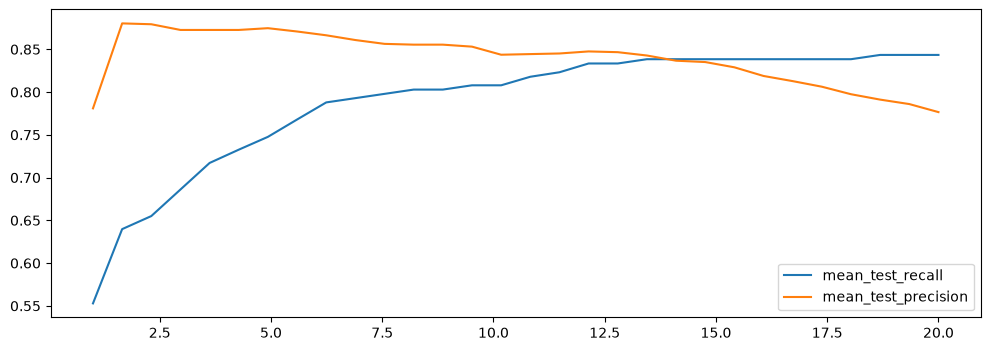

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
df=pd.DataFrame(grid.cv_results_)
for score in ['mean_test_recall','mean_test_precision']:
    plt.plot([_[1] for _ in df['param_class_weight']],
    df[score], label=score)

plt.legend();

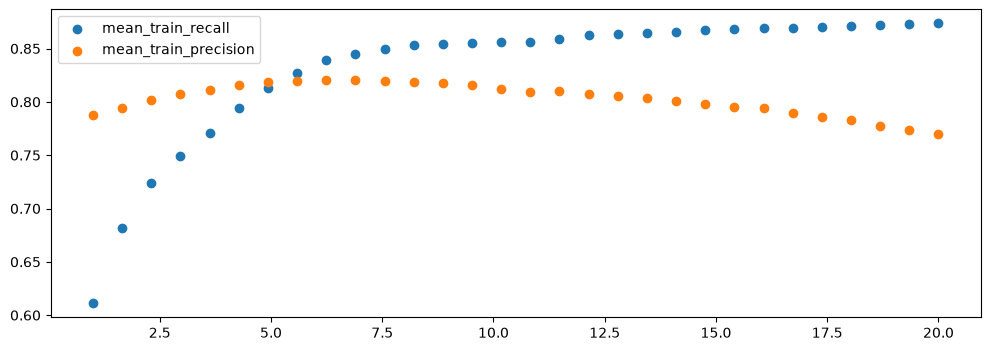

In [87]:
plt.figure(figsize=(12,4))
df=pd.DataFrame(grid.cv_results_)
for score in ['mean_train_recall','mean_train_precision']:
    plt.scatter(x=[_[1] for _ in df['param_class_weight']],
    y=df[score.replace('test','train')],label=score)

plt.legend()

## implement out own metrix

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, make_scorer
import numpy as np
import pandas as pd

def min_recall_precision(y_true,y_pred):
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true,y_pred)
    return min(recall,precision)


grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid = {'class_weight':[{0:1,1:v} for v in np.linspace(1,20,30)]},
    cv = 10,
    scoring={'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'min_both' : make_scorer(min_recall_precision)},
    refit='min_both', # to tell the gridsearch to chose precision to find the best model
    return_train_score=True,
    n_jobs=-1 # use 100% available cpu
)

grid.fit(X,y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [{0: 1, 1: np.float64(1.0)}, {0: 1, 1: np.float64(1.6551724137931034)}, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'min_both': make_scorer(m...hod='predict'), 'precision': make_scorer(p...hod='predict'), 'recall': make_scorer(r...hod='predict')}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'precision'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be

In [89]:
pd.set_option('display.max_columns',None)
pd.DataFrame(grid.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_class_weight,params,split0_test_precision,split1_test_precision,split2_test_precision,split3_test_precision,split4_test_precision,split5_test_precision,split6_test_precision,split7_test_precision,split8_test_precision,split9_test_precision,mean_test_precision,std_test_precision,rank_test_precision,split0_train_precision,split1_train_precision,split2_train_precision,split3_train_precision,split4_train_precision,split5_train_precision,split6_train_precision,split7_train_precision,split8_train_precision,split9_train_precision,mean_train_precision,std_train_precision,split0_test_recall,split1_test_recall,split2_test_recall,split3_test_recall,split4_test_recall,split5_test_recall,split6_test_recall,split7_test_recall,split8_test_recall,split9_test_recall,mean_test_recall,std_test_recall,rank_test_recall,split0_train_recall,split1_train_recall,split2_train_recall,split3_train_recall,split4_train_recall,split5_train_recall,split6_train_recall,split7_train_recall,split8_train_recall,split9_train_recall,mean_train_recall,std_train_recall,split0_test_min_both,split1_test_min_both,split2_test_min_both,split3_test_min_both,split4_test_min_both,split5_test_min_both,split6_test_min_both,split7_test_min_both,split8_test_min_both,split9_test_min_both,mean_test_min_both,std_test_min_both,rank_test_min_both,split0_train_min_both,split1_train_min_both,split2_train_min_both,split3_train_min_both,split4_train_min_both,split5_train_min_both,split6_train_min_both,split7_train_min_both,split8_train_min_both,split9_train_min_both,mean_train_min_both,std_train_min_both
0,0.493718,0.119422,0.024268,0.005581,"{0: 1, 1: 1.0}","{'class_weight': {0: 1, 1: 1.0}}",1.000000,0.463415,0.583333,1.000000,1.000000,0.944444,1.0,0.818182,0.0,1.000000,0.780937,0.319029,29,0.801471,0.916667,0.854962,0.761538,0.759398,0.753731,0.744361,0.767606,0.763889,0.751773,0.787540,0.053033,0.368421,1.0,0.736842,0.473684,0.35,0.85,0.90,0.45,0.00,0.40,0.552895,0.293874,30,0.615819,0.745763,0.632768,0.559322,0.573864,0.573864,0.562500,0.619318,0.625000,0.602273,0.611049,0.051750,0.368421,0.463415,0.583333,0.473684,0.35,0.850000,0.90,0.450000,0.00,0.40,0.483885,0.243144,30,0.615819,0.745763,0.632768,0.559322,0.573864,0.573864,0.562500,0.619318,0.625000,0.602273,0.611049,0.051750
1,0.532189,0.142351,0.026125,0.015227,"{0: 1, 1: 1.6551724137931034}","{'class_weight': {0: 1, 1: 1.6551724137931034}}",1.000000,0.441860,0.583333,1.000000,1.000000,0.944444,1.0,0.833333,1.0,1.000000,0.880297,0.193056,1,0.768212,0.924051,0.835616,0.765517,0.776316,0.770270,0.765517,0.784314,0.778481,0.775641,0.794394,0.047412,0.421053,1.0,0.736842,0.789474,0.35,0.85,0.95,0.50,0.25,0.55,0.639737,0.247661,29,0.655367,0.824859,0.689266,0.627119,0.670455,0.647727,0.630682,0.681818,0.698864,0.687500,0.681366,0.053324,0.421053,0.441860,0.583333,0.789474,0.35,0.850000,0.95,0.500000,0.25,0.55,0.568572,0.215831,29,0.655367,0.824859,0.689266,0.627119,0.670455,0.647727,0.630682,0.681818,0.698864,0.687500,0.681366,0.053324
2,0.572018,0.156246,0.024001,0.009582,"{0: 1, 1: 2.310344827586207}","{'class_weight': {0: 1, 1: 2.310344827586207}}",1.000000,0.431818,0.583333,1.000000,1.000000,0.944444,1.0,0.833333,1.0,1.000000,0.879293,0.195347,2,0.773585,0.919753,0.838710,0.775641,0.787500,0.782051,0.774194,0.793750,0.789157,0.785276,0.801962,0.043139,0.421053,1.0,0.736842,0.842105,0.40,0.85,0.95,0.50,0.25,0.60,0.655000,0.244257,28,0.694915,0.841808,0.734463,0.683616,0.715909,0.693182,0.681818,0.721591,0.744318,0.727273,0.723889,0.044372,0.421053,0.431818,0.583333,0.842105,0.40,0.850000,0.95,0.500000,0.25,0.60,0.582831,0.217659,28,0.694915,0.841808,0.734463,0.683616,0.715909,0.693182,0.681818,0.721591,0.744318,0.727273,0.723889,0.044372
3,0.596893,0.166022,0.024686,0.012410,"{0: 1, 1: 2.9655172413793105}","{'class_weight': {0: 1, 1: 2.9655172413793105}}",1.000000,0.431818,0.583333,1.000000,1.000000,0.944444,1.0,0.833333,1.0,0.933333,0.872626,0.192226,4,0.776398,0.91

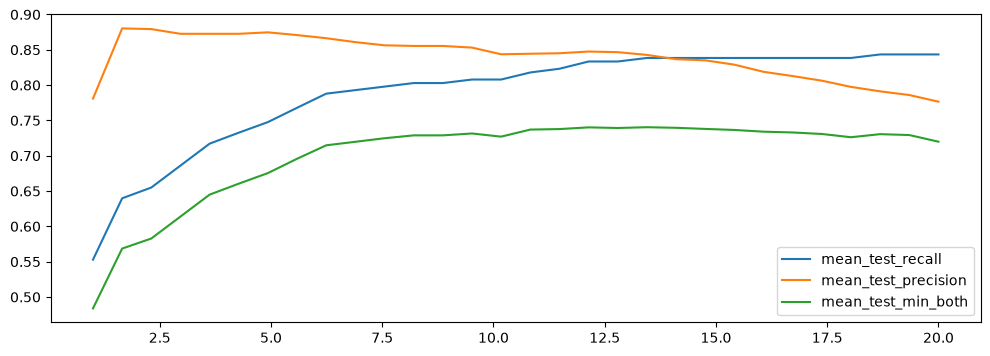

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
df=pd.DataFrame(grid.cv_results_)
for score in ['mean_test_recall','mean_test_precision','mean_test_min_both']:
    plt.plot([_[1] for _ in df['param_class_weight']],
    df[score], label=score)

plt.legend()

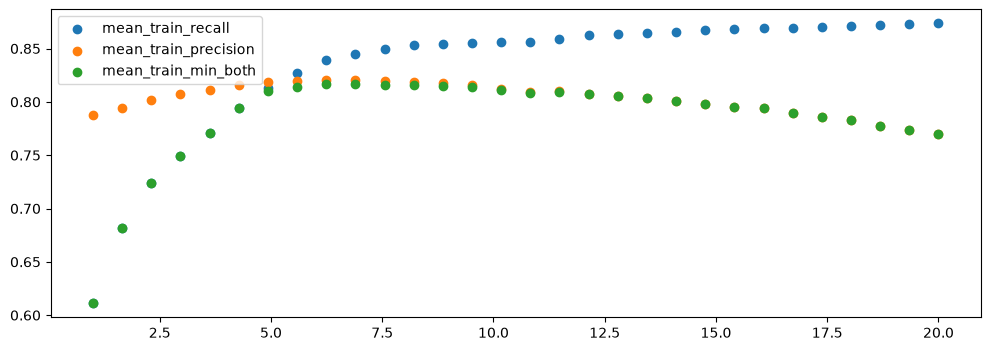

In [91]:
plt.figure(figsize=(12,4))
df=pd.DataFrame(grid.cv_results_)
for score in ['mean_train_recall','mean_train_precision', 'mean_train_min_both']:
    plt.scatter(x=[_[1] for _ in df['param_class_weight']],
    y=df[score.replace('test','train')],label=score)

plt.legend()

## rewrite the custome fuction to include make_score function inside it

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, make_scorer
import numpy as np
import pandas as pd

def min_recall_precision(est, X, y_true,sample_weight=None):
    y_pred = est.predict(X)
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true,y_pred)
    return min(recall,precision)


grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid = {'class_weight':[{0:1,1:v} for v in np.linspace(1,20,30)]},
    cv = 10,
    scoring={'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'min_both' : min_recall_precision},
    refit='min_both', # to tell the gridsearch to chose precision to find the best model
    return_train_score=True,
    n_jobs=-1 # use 100% available cpu
)

grid.fit(X,y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [{0: 1, 1: np.float64(1.0)}, {0: 1, 1: np.float64(1.6551724137931034)}, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'min_both': <function min...001AC1E35A160>, 'precision': make_scorer(p...hod='predict'), 'recall': make_scorer(r...hod='predict')}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'precision'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be

### using sample_weight to give some importance to some rows

In [110]:
# i got erros for the below code

In [ ]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import precision_score, recall_score, make_scorer
# import numpy as np
# import pandas as pd

# def min_recall_precision(est, X, y_true,sample_weight=None):
#     y_pred = est.predict(X)
#     recall = recall_score(y_true, y_pred)
#     precision = precision_score(y_true,y_pred)
#     return min(recall,precision)


# grid = GridSearchCV(
#     estimator=LogisticRegression(max_iter=1000),
#     param_grid = {'class_weight':[{0:1,1:v} for v in np.linspace(1,20,30)]},
#     cv = 10,
#     scoring={'precision': make_scorer(precision_score),
#     'recall': make_scorer(recall_score),
#     'min_both' : min_recall_precision
    
#     },
#     refit='min_both', # to tell the gridsearch to chose precision to find the best model
#     return_train_score=True,
#     n_jobs=-1 # use 100% available cpu
# )

# grid.fit(X,y, sample_weight=np.log(1 + df['Amount']))

c:\Users\pkmpp\Documents\Obsidian\Obsidian\ML_AI_DL\Scikit-learn\Scikit-learn\Notebook\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
c:\Users\pkmpp\Documents\Obsidian\Obsidian\ML_AI_DL\Scikit-learn\Scikit-learn\Notebook\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the train scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [{0: 1, 1: np.float64(1.0)}, {0: 1, 1: np.float64(1.6551724137931034)}, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'min_both': make_scorer(m...hod='predict'), 'precision': make_scorer(p...hod='predict'), 'recall': make_scorer(r...hod='predict')}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'min_both'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be 

In [113]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, make_scorer
import numpy as np
import pandas as pd

def min_recall_precision(y_true, y_pred, sample_weight=None):
    recall = recall_score(y_true, y_pred, sample_weight=sample_weight)
    precision = precision_score(y_true, y_pred, sample_weight=sample_weight)
    return min(recall, precision)


grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid = {'class_weight':[{0:1,1:v} for v in np.linspace(1,20,30)]},
    cv = 10,
    scoring={
        'precision': make_scorer(precision_score),
        'recall': make_scorer(recall_score),
        'min_both' : make_scorer(min_recall_precision)
    },
    refit='min_both', # to tell the gridsearch to chose precision to find the best model
    return_train_score=True,
    n_jobs=-1 # use 100% available cpu
)

grid.fit(X,y, sample_weight=np.log(1 + df['Amount']))

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [{0: 1, 1: np.float64(1.0)}, {0: 1, 1: np.float64(1.6551724137931034)}, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'min_both': make_scorer(m...hod='predict'), 'precision': make_scorer(p...hod='predict'), 'recall': make_scorer(r...hod='predict')}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'min_both'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be 

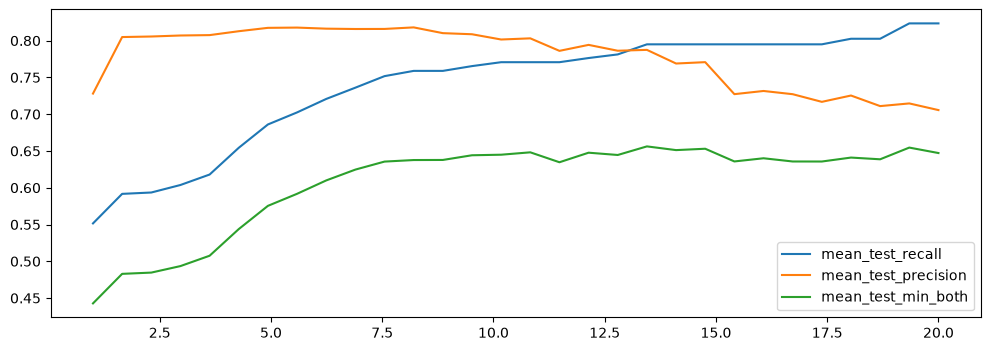

In [114]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
df=pd.DataFrame(grid.cv_results_)
for score in ['mean_test_recall','mean_test_precision','mean_test_min_both']:
    plt.plot([_[1] for _ in df['param_class_weight']],
    df[score], label=score)

plt.legend()

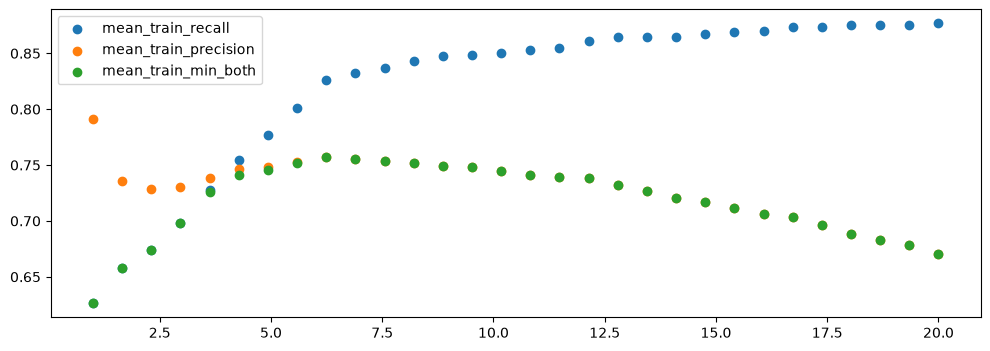

In [115]:
plt.figure(figsize=(12,4))
df=pd.DataFrame(grid.cv_results_)
for score in ['mean_train_recall','mean_train_precision', 'mean_train_min_both']:
    plt.scatter(x=[_[1] for _ in df['param_class_weight']],
    y=df[score.replace('test','train')],label=score)

plt.legend()

### outlier detectin algorithm

In [117]:
from collections import Counter
from sklearn.ensemble import IsolationForest
mod = IsolationForest().fit(X)
Counter(mod.predict(X))

Counter({np.int64(1): 76988, np.int64(-1): 3012})

In [118]:
np.where(mod.predict(X) == -1 , 1, 0)

array([0, 0, 0, ..., 0, 0, 0], shape=(80000,))

In [120]:
from sklearn.model_selection import GridSearchCV

def outlier_precision(mod, X,y):
    pred = mod.predict(X)
    return precision_score(y,np.where(pred == -1,1,0))

def outlier_recall(mod, X, y):
    pred = mod.predict(X)
    return recall_score(y,np.where(pred == -1,1,0))


grid = GridSearchCV(
    estimator=IsolationForest(),
    param_grid={
        'contamination': np.linspace(0.001,0.02,10)
    },
    scoring = {
        'precision': outlier_precision,
        'recall': outlier_recall
    },
    refit="precision",
    cv=5,
    n_jobs=1
)

grid.fit(X,y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",IsolationForest()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'contamination': array([0.001 ..., 0.02 ])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'precision': <function out...001AC1D767F60>, 'recall': <function out...001AC1D767420>}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'precision'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose

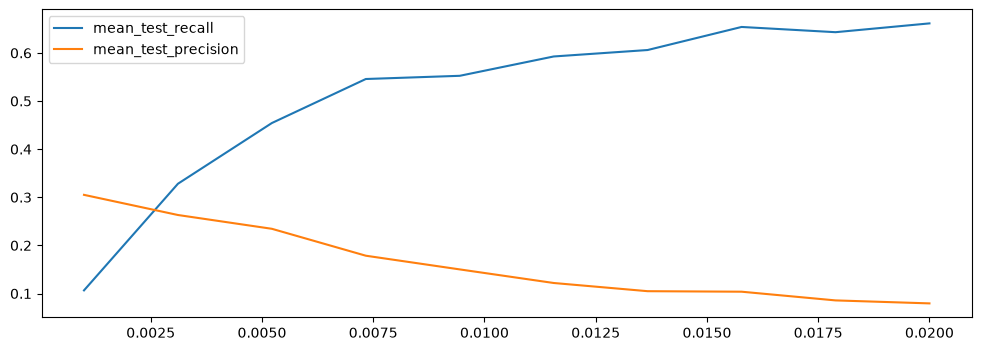

In [123]:
plt.figure(figsize=(12,4))
df_result=pd.DataFrame(grid.cv_results_)
for score in ['mean_test_recall','mean_test_precision']:
    plt.plot(df_result['param_contamination'],df_result[score],label=score)

plt.legend()

In [127]:
?make_scorer

Signature:
make_scorer(
    score_func,
    *,
    response_method='predict',
    greater_is_better=True,
    **kwargs,
)
Docstring:
Make a scorer from a performance metric or loss function.

A scorer is a wrapper around an arbitrary metric or loss function that is called
with the signature `scorer(estimator, X, y_true, **kwargs)`.

It is accepted in all scikit-learn estimators or functions allowing a `scoring`
parameter.

The parameter `response_method` allows to specify which method of the estimator
should be used to feed the scoring/loss function.

Read more in the :ref:`User Guide <scoring_callable>`.

Parameters
----------
score_func : callable
    Score function (or loss function) with signature
    ``score_func(y, y_pred, **kwargs)``.

response_method : {"predict_proba", "decision_function", "predict"} or             list/tuple of such str, default="predict"

    Specifies the response method to use get prediction from an estimator
    (i.e. :term:`predict_proba`, :term:`decisio